# Notebook 2 — Object Detection & Segmentation

Raw RGB frames are the starting point for scene understanding.
This notebook covers the two perception stages: detecting *what is where*
(YOLO bounding boxes) and delineating *exactly which pixels* belong to each object (SAM masks).

---

## Prerequisites

| Topic | Why it matters |
|-------|---------------|
| Convolutional neural networks | YOLO and SAM are CNN/ViT-based models |
| Bounding boxes (XYXY format) | YOLO output representation |
| Binary masks | SAM output representation |
| CLIP-style embeddings | SigLIP image/text feature alignment |

---

## Learning Objectives

1. Run open-world YOLO detection on an RGB frame.
2. Refine bounding boxes to pixel masks with SAM2.
3. Understand the mask quality filter and its parameters.
4. Embed cropped objects with SigLIP for downstream tracking.

## 1 · Perception Pipeline Overview

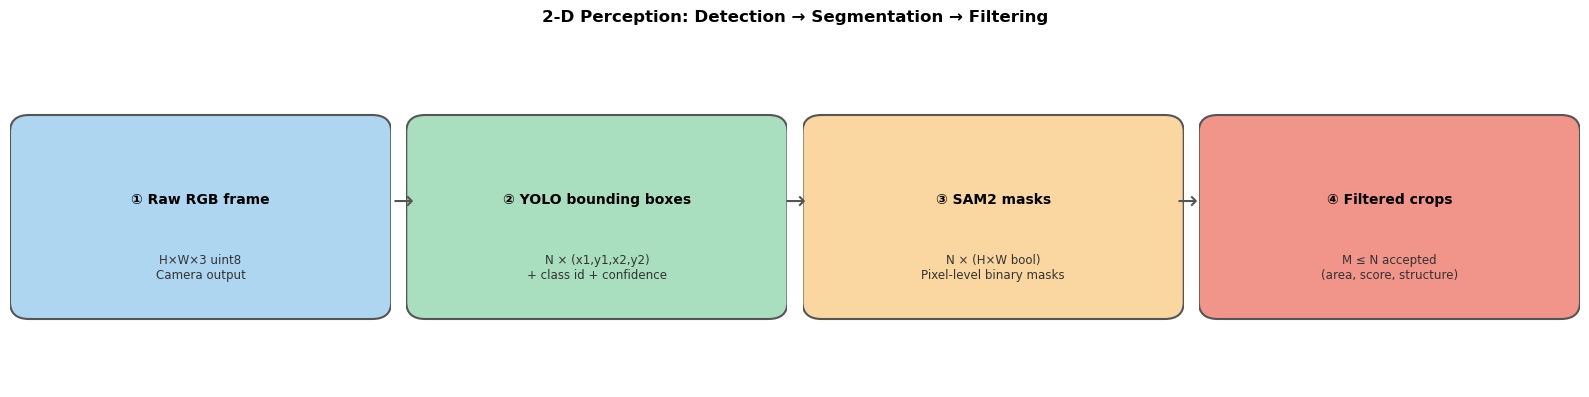

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['① Raw RGB frame', '② YOLO bounding boxes', '③ SAM2 masks', '④ Filtered crops']
colors = ['#AED6F1', '#A9DFBF', '#FAD7A0', '#F1948A']
descriptions = [
    'H×W×3 uint8\nCamera output',
    'N × (x1,y1,x2,y2)\n+ class id + confidence',
    'N × (H×W bool)\nPixel-level binary masks',
    'M ≤ N accepted\n(area, score, structure)',
]

for ax, title, col, desc in zip(axes, titles, colors, descriptions):
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.25), 0.9, 0.5,
        boxstyle='round,pad=0.05', facecolor=col, edgecolor='#555', lw=1.5,
        transform=ax.transAxes))
    ax.text(0.5, 0.55, title, ha='center', va='center', fontsize=10,
            fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.35, desc, ha='center', va='center', fontsize=8.5,
            transform=ax.transAxes, color='#333')
    ax.axis('off')

for i in range(3):
    fig.text(0.255 + i*0.245, 0.5, '→', fontsize=18, ha='center', va='center', color='#555')

plt.suptitle('2-D Perception: Detection → Segmentation → Filtering', fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 2 · Open-World Detection with YOLO

### Why YOLO?

YOLO (You Only Look Once) processes an entire image in a **single forward pass**,
making it fast enough for real-time robotic use (~30 ms per frame on a GPU).

The system uses YOLOv8 or YOLOv11 in **open-vocabulary mode**: instead of the default
80 COCO classes, we supply a custom list of architectural and furniture categories
from `cfg.landmarks` and `cfg.openset`.

### Output format

```
bboxes  : (N, 4)  – [x_min, y_min, x_max, y_max] in pixel coordinates (XYXY)
class_ids : (N,)  – integer index into cfg.landmarks['classes']
confidences : (N,) – float in [0, 1]
```

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.float = np.float64
np.int = np.int_

from PIL import Image
from spot_semantic_mapping.configs.loader import cfg
from spot_semantic_mapping.models.detection import YOLODetector

# ── Load a sample frame ──────────────────────────────────────────────────────
IPHONE_PATH = '../data/iphone/3578aa5730'
import skvideo.io
video = skvideo.io.vreader(os.path.join(IPHONE_PATH, 'rgb.mp4'))
frames = [f for _, f in zip(range(100), video)]

#quick note: iphone recorded in portrait mode, so frames are H×W×3 with H > W (they are rotated compared to typical landscape images)
#before feeding into the model, we will rotate them to landscape orientation (W×H×3) which is what the model expects
frames = [np.rot90(f, k=-1) for f in frames]  # rotate -90 degrees

rgb = frames[80]   # pick a frame with interesting objects

# ── Run detector ─────────────────────────────────────────────────────────────
detector = YOLODetector(cfg)
bboxes, class_ids, confs = detector(rgb)
print(f'Detected {len(bboxes)} objects')
for bbox, cid, conf in zip(bboxes, class_ids, confs):
    class_name = cfg.landmarks['classes'][cid]
    print(f'  {class_name:<20s}  conf={conf:.2f}  box={np.round(bbox).astype(int).tolist()}')

[YOLO Detector] Loading src/models/weights/yolov8l-world.pt
Detected 3 objects
  tv_stand              conf=0.44  box=[323, 826, 681, 1176]
  tv_stand              conf=0.41  box=[0, 844, 243, 1275]
  desk                  conf=0.41  box=[3, 1117, 686, 1907]


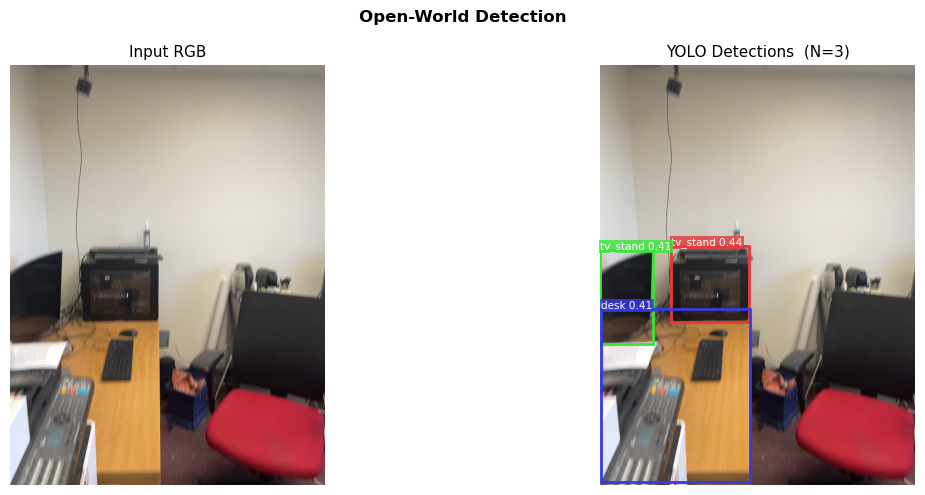

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import colorsys

def bbox_colours(n):
    return [colorsys.hsv_to_rgb(i/max(n,1), 0.75, 0.9) for i in range(n)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: raw frame ───────────────────────────────────────────────────────────
axes[0].imshow(rgb); axes[0].set_title('Input RGB', fontsize=11); axes[0].axis('off')

# ── Right: detections ─────────────────────────────────────────────────────────
axes[1].imshow(rgb); axes[1].set_title(f'YOLO Detections  (N={len(bboxes)})', fontsize=11)
colours = bbox_colours(len(bboxes))
for (x1,y1,x2,y2), cid, conf, c in zip(bboxes, class_ids, confs, colours):
    label = f"{cfg.landmarks['classes'][cid]} {conf:.2f}"
    axes[1].add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1,
        linewidth=2, edgecolor=c, facecolor='none'))
    axes[1].text(x1, y1-4, label, fontsize=7.5, color='white',
                 bbox=dict(facecolor=c, alpha=0.8, pad=1, edgecolor='none'))
axes[1].axis('off')

plt.suptitle('Open-World Detection', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3 · Mask Refinement with SAM2

### Why mask refinement?

YOLO gives us coarse rectangles.
For accurate 3-D reconstruction we need **pixel-precise masks** —
otherwise we include background depth pixels in each object's point cloud.

**SAM2** (Segment Anything v2) is a promptable segmentation model.
We use **bbox-prompting**: the YOLO bounding box acts as a spatial prior that
tells SAM2 which region to segment, dramatically reducing ambiguity.

```
RGB image  ──┐
              ├──► SAM2 ──► binary mask (H, W, bool)
YOLO bbox  ──┘
```

### Backend options

| Backend | Speed | Quality | Use case |
|---------|-------|---------|----------|
| `sam2` | Slow (~400 ms) | Highest | Offline processing |
| `mobilesam` | Medium (~80 ms) | Good | Real-time on GPU |
| `fastsam` | Fast (~40 ms) | Moderate | Edge deployment |

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from spot_semantic_mapping.models.segmentation import SAM2Predictor, MobileSAMPredictor

sam = SAM2Predictor(cfg)       # swap for MobileSAMPredictor if faster needed
masks = sam(rgb, bboxes=bboxes, verbose=False)

print(f'SAM2 returned {len(masks)} masks')
for i, m in enumerate(masks[:5]):
    label = cfg.landmarks['classes'][class_ids[i]]
    print(f'  mask[{i}]  {label:<18s}  coverage: {m.mean()*100:.1f}% of image')

[SAM2] Loading src/models/weights/sam2.1_b.pt → cuda
SAM2 returned 3 masks
  mask[0]  tv_stand            coverage: 4.3% of image
  mask[1]  tv_stand            coverage: 2.9% of image
  mask[2]  desk                coverage: 8.6% of image


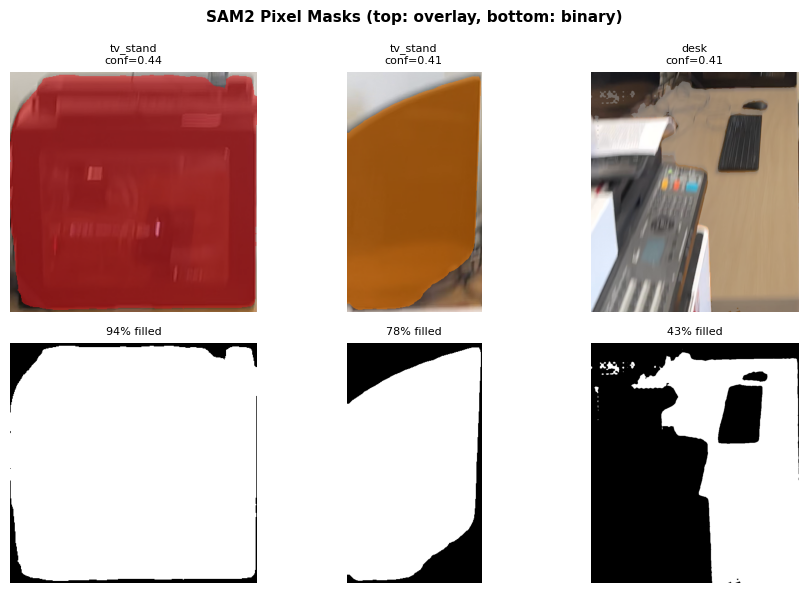

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

n_show = min(6, len(masks))
fig, axes = plt.subplots(2, n_show, figsize=(3*n_show, 6))
if n_show == 1:
    axes = axes[:, np.newaxis]

# Colour palette
palette = plt.cm.Set1(np.linspace(0, 1, n_show))

for i in range(n_show):
    label = cfg.landmarks['classes'][class_ids[i]]
    x1,y1,x2,y2 = bboxes[i].astype(int)
    crop = rgb[y1:y2, x1:x2]
    crop_mask = masks[i][y1:y2, x1:x2]

    # Top row: crop with mask overlay
    overlay = crop.copy()
    col = (np.array(palette[i][:3]) * 255).astype(np.uint8)
    overlay[crop_mask] = (overlay[crop_mask] * 0.45 + col * 0.55).astype(np.uint8)
    axes[0, i].imshow(overlay)
    axes[0, i].set_title(f'{label}\nconf={confs[i]:.2f}', fontsize=8)
    axes[0, i].axis('off')

    # Bottom row: binary mask
    axes[1, i].imshow(crop_mask, cmap='gray')
    coverage = crop_mask.mean() * 100
    axes[1, i].set_title(f'{coverage:.0f}% filled', fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('RGB + mask overlay', fontsize=9)
axes[1, 0].set_ylabel('Binary mask', fontsize=9)
plt.suptitle('SAM2 Pixel Masks (top: overlay, bottom: binary)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 4 · Mask Quality Filtering

Not every mask is useful. Before lifting to 3-D we reject masks that are:

| Filter | Criterion | Why |
|--------|-----------|-----|
| **Too small** | `mask_area < min_mask_area_percent × H×W` | Avoids noisy detections |
| **Low confidence** | `conf < min_confidence` | Reduces false positives |
| **Large structure** | Large area AND large 3-D extent | Removes walls/floors/ceilings |
| **Contained** | Significant overlap with another larger mask | Avoids double-counting |

The last filter is non-trivial — it uses the **intersection-over-union (IoU)**
computed in 2-D:

$$
\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$

In [18]:
from spot_semantic_mapping.mapping.pipeline import run_yolo_sam, filter_masks

# Convenience wrapper: detect + segment in one call
masks_all, ids_all, confs_all, _ = run_yolo_sam(rgb, detector, sam, cfg)
masks_filt, confs_filt, ids_filt = filter_masks(masks_all, confs_all, ids_all, cfg)

print(f'Before filtering: {len(masks_all)} masks')
print(f'After  filtering: {len(masks_filt)} masks  '
      f'({len(masks_all)-len(masks_filt)} removed)')

# Show filtering config
print('\nFilter thresholds:')
print(f"  min_confidence       = {cfg.segmentation['min_confidence']}")
print(f"  min_mask_area_percent= {cfg.segmentation['min_mask_area_percent']}")
print(f"  mask_merge_iou       = {cfg.segmentation['mask_merge_iou']}")

Before filtering: 3 masks
After  filtering: 3 masks  (0 removed)

Filter thresholds:
  min_confidence       = 0.25
  min_mask_area_percent= 0.1
  mask_merge_iou       = 0.7


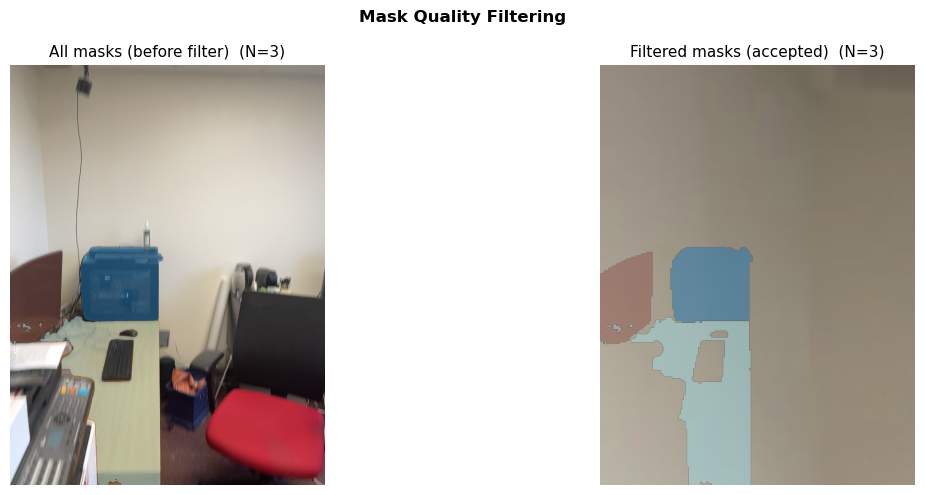

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def overlay_all_masks(ax, image, masks, ids, title):
    ax.imshow(image)
    palette = plt.cm.tab20(np.linspace(0, 1, max(len(masks), 1)))
    for i, (m, cid) in enumerate(zip(masks, ids)):
        colour = palette[i % 20][:3]
        coloured = np.zeros((*m.shape, 4))
        coloured[m] = [*colour, 0.5]
        ax.imshow(coloured)
    ax.set_title(f'{title}  (N={len(masks)})', fontsize=11)
    ax.axis('off')

overlay_all_masks(axes[0], rgb, masks_all,  ids_all,  'All masks (before filter)')
overlay_all_masks(axes[1], rgb, masks_filt, ids_filt, 'Filtered masks (accepted)')
plt.suptitle('Mask Quality Filtering', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 · Semantic Embeddings with SigLIP

After filtering, each accepted mask is **cropped** from the RGB image and
embedded into a 768-dimensional feature vector using **SigLIP**
(Sigmoid Loss for Language-Image Pre-Training).

SigLIP is a vision-language model: it maps both images and text into the *same*
embedding space, so we can compute similarity between
"a photo of a chair" and an image crop directly.

These embeddings are stored on each `Detection` object and later used by the tracker
to decide whether a new detection matches an existing 3-D object.

$$
\text{sim}(\mathbf{i}, \mathbf{t}) = \cos(\phi_{\text{img}}(\mathbf{i}),\, \phi_{\text{text}}(\mathbf{t}))
$$

In [ ]:
import torch
from spot_semantic_mapping.models.embedding import SiglipModel

siglip = SiglipModel(cfg)

# note1: in a real application we would want to batch these together instead of one at a time, but for demonstration we'll do them sequentially here since there are only a few
# note2: SigLipModel, or most embedding models, are trained with a specific size of input, so we will need to look it up and resize the crops to that size before embedding (SigLipModel uses 224×224)

# Crop and embed the accepted masks
crops_pil = []
for m, (x1,y1,x2,y2) in zip(masks_filt, bboxes[np.where(
        np.isin(np.arange(len(masks_all)), [i for i,m in enumerate(masks_all) if m in masks_filt])
    )[0][:len(masks_filt)]]):
    y1,y2,x1,x2 = int(y1),int(y2),int(x1),int(x2)
    crops_pil.append(Image.fromarray(rgb[y1:y2, x1:x2]))

if crops_pil:
    with torch.no_grad():
        img_feats = siglip.embed_images(crops_pil)   # (M, D)
    print(f'Embedded {len(crops_pil)} crops → shape {img_feats.shape}')

    # Text-image similarity for all detected objects
    class_names = [cfg.landmarks['classes'][c] for c in ids_filt]
    text_feats = siglip.embed_texts([f'a photo of a {n}' for n in class_names])
    sims = (img_feats * text_feats).sum(dim=-1).cpu().numpy()
    print('\nImage–text cosine similarities:')
    for name, s in zip(class_names, sims):
        bar = '█' * int(s * 30)
        print(f'  {name:<22s}  {s:.3f}  {bar}')

[SigLIP] Loading google/siglip-base-patch16-384 → cuda


preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/814M [00:00<?, ?B/s]

ValueError: operands could not be broadcast together with shapes (256,192) (1920,1440) 

## Summary

| Stage | Model | Output | Key parameter |
|-------|-------|--------|---------------|
| Detection | YOLO v8/v11 | N bboxes + class ids | `cfg.landmarks.classes` |
| Segmentation | SAM2 / MobileSAM | N binary masks | `segmentation.sam_backend` |
| Filtering | Rule-based | M ≤ N masks | `min_mask_area_percent`, `min_confidence` |
| Embedding | SigLIP | M × 768 feature vectors | — |

**Next:** Notebook 3 takes these 2-D detections and builds a persistent 3-D scene graph.